In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pathlib
import warnings
import datetime
warnings.simplefilter("ignore", FutureWarning)

from demand_ninja.core import demand

curr_dir = pathlib.Path(".")
data_dir = curr_dir / "RTS-GMLC-master" / "RTS_Data"
load_data_dir = curr_dir / "load-data"

### Converting weather data to load data with DemandNinja

In [14]:
# Read in list of buses
df_bus = pd.read_csv(curr_dir / "RTS-GMLC-master" / "RTS_Data" / "SourceData" / "bus.csv", index_col=[0])

In [17]:
pd.read_csv(fname)

,Year,Month,Day,Hour,Minute,GHI,DNI,DHI,Temperature,Wind Speed
0,2019,1,1,0,30,0,0,0,-1.0,2.0
1,2019,1,1,1,30,0,0,0,-1.3,2.3
2,2019,1,1,2,30,0,0,0,-1.4,2.8
3,2019,1,1,3,30,0,0,0,-1.4,3.2
4,2019,1,1,4,30,0,0,0,-1.7,3.4
...,...,...,...,...,...,...,...,...,...,...
8755,2019,12,31,19,30,0,0,0,2.8,1.6
8756,2019,12,31,20,30,0,0,0,1.7,1.7
8757,2019,12,31,21,30,0,0,0,0.8,1.8
8758,2019,12,31,22,30,0,0,0,0.1,1.9


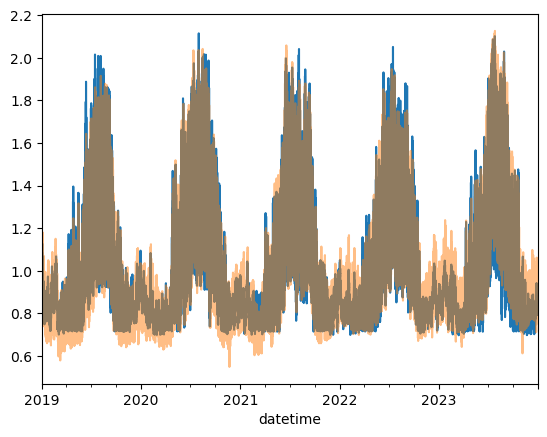

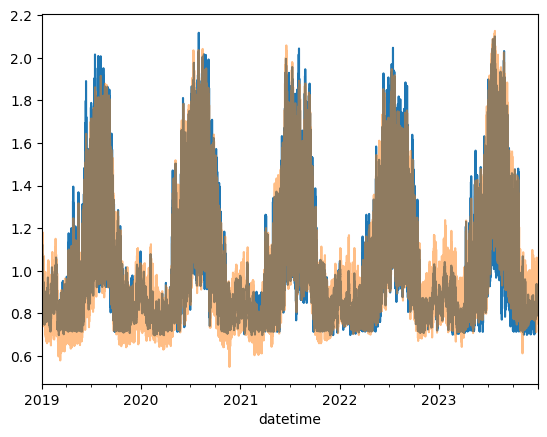

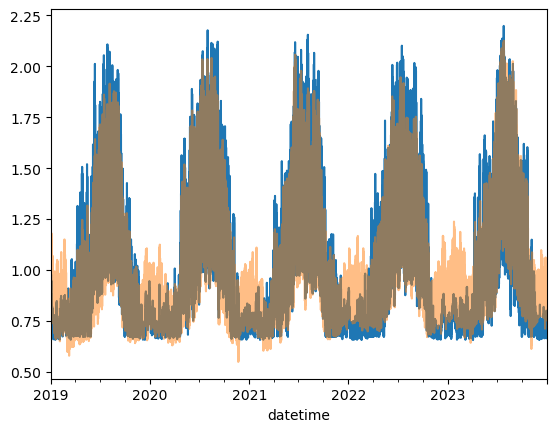

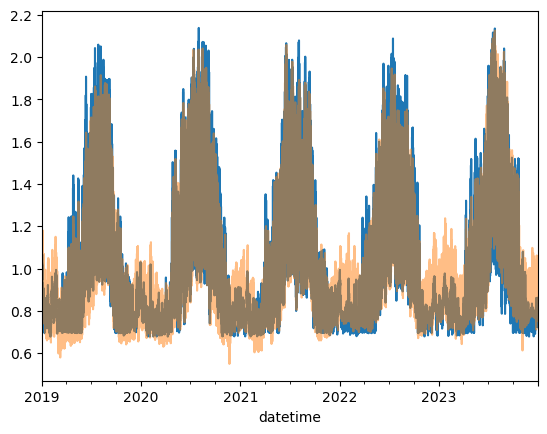

ValueError: Index datetime invalid

In [15]:
# Read in NSRDB input data
for bus in df_bus.index:
    bus_data_files = sorted(list((load_data_dir / "formatted" / str(bus)).glob("*.csv")))
    
    years = [2019, 2020, 2021, 2022, 2023]
    df_in_concat = pd.DataFrame()
    for fname in bus_data_files:
        if int(fname.stem.split("_")[-1]) in years:
            df_in = pd.read_csv(fname, index_col=["datetime"])
            df_in.index = pd.to_datetime(df_in.index)
            df_in.index -= pd.Timedelta(hours=0.5)
            
            # Get subset of columns needed for load calculation in demand ninja
            df_in = df_in[["Temperature", "Relative Humidity", "GHI", "Wind Speed"]]
            df_in.columns = ["temperature", "humidity", "radiation_global_horizontal", "wind_speed_2m"]
            df_in_concat = pd.concat([df_in_concat, df_in])
    df_in = df_in_concat.copy()
    
    # Calculate demand with demand ninja
    df_out = demand(
        df_in,
        base_power=12,
        heating_power=0.7,
        cooling_power=1.2,
        cooling_threshold=15.0,
        heating_threshold=23.0,
        humidity_discomfort=0.003,
        solar_gains=0.01,
        smoothing=0.1,
    )["total_demand"]
    
    # Get subset of Southwest demand for years
    df_sw = df_sw.loc[df_sw.index.year.isin(years)]

    # Plot
    df_out_norm = df_out / df_out.mean()
    df_sw_norm = df_sw / df_sw.mean()
    df_out_norm.plot()
    df_sw_norm.plot(alpha=0.5)

    plt.scatter(df_in["temperature"], df_out_norm, s=3, alpha=0.1)
    plt.scatter(df_in["temperature"], df_sw_norm, s=3, alpha=0.1)
    plt.show()

In [16]:
fname

PosixPath('load-data/formatted/105/bus105_weather_2019.csv')

### Downloading + processing EIA load data

In [ ]:
# Read in API key
with open("eia-api-key.txt", "r") as f:
    API_KEY = f.readlines()[0].strip()

In [ ]:
BASE_URL = "https://api.eia.gov/v2/electricity/rto/region-data/data/"

RESPONDENTS = ["AZPS", "PNM", "SRP"]

START_DATE = "2016-01-01T00"
END_DATE   = "2018-12-31T00"

MAX_ROWS = 5000  # API row limit per request
DELAY = 0.2      # seconds between requests to avoid rate limits

def fetch_page(offset=0):
    """Fetch a single page of results from the EIA API."""
    params = {
        "api_key": API_KEY,
        "frequency": "hourly",
        "data[0]": "value",
        "facets[respondent][]": RESPONDENTS,
        "start": START_DATE,
        "end": END_DATE,
        "sort[0][column]": "period",
        "sort[0][direction]": "desc",
        "offset": offset,
        "length": MAX_ROWS
    }
    response = requests.get(BASE_URL, params=params)
    response.raise_for_status()
    data = response.json().get("response", {}).get("data", [])
    return data

def fetch_all_data():
    """Fetch all rows by paginating through the API."""
    all_data = []
    offset = 0
    
    while True:
        print(f"Fetching rows starting at offset {offset} ...")
        page = fetch_page(offset)
        if not page:
            break
        all_data.extend(page)
        if len(page) < MAX_ROWS:
            break
        offset += MAX_ROWS
        time.sleep(DELAY)
    
    print(f"Total rows fetched: {len(all_data)}")
    return all_data

def main():
    data = fetch_all_data()
    if not data:
        print("No data retrieved.")
        return
    
    df = pd.DataFrame(data)
    df['datetime'] = pd.to_datetime(df['period'])
    df = df.sort_values(['respondent', 'datetime'])
    
    # Save to CSV
    df.to_csv("EIA_hourly_load_2016_2018.csv", index=False)
    print("Saved to EIA_hourly_load_2016_2018.csv")

if __name__ == "__main__":
    main()

In [2]:
# Read-in and organize load data
df = pd.read_csv(load_data_dir / "historical" / "EIA_hourly_load_2019_2025.csv")
df_load = df.loc[df["type-name"] == "Demand"]
df_load = df_load.pivot(index=["datetime"], columns=["respondent"], values=["value"])
df_load.columns = df_load.columns.droplevel(0)
df_load.index = pd.to_datetime(df_load.index)

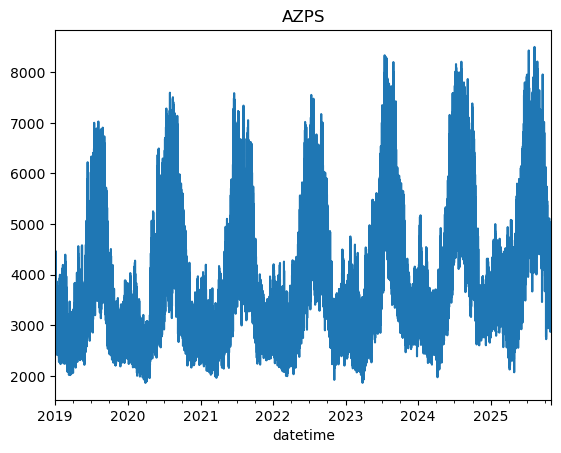

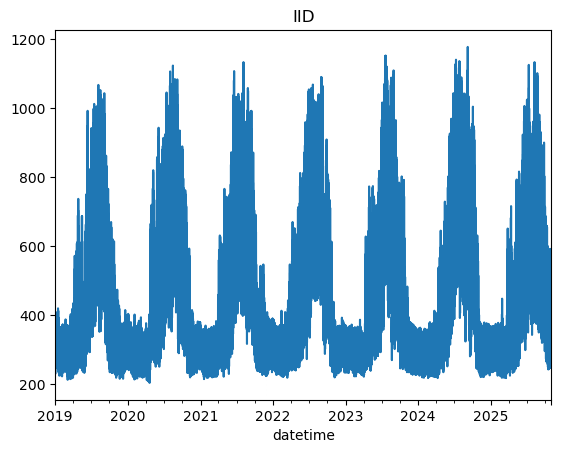

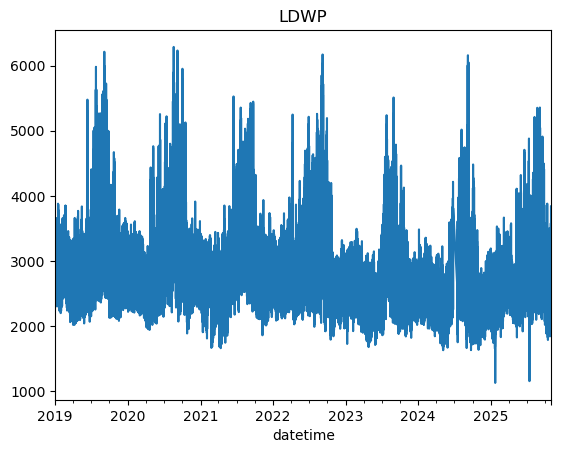

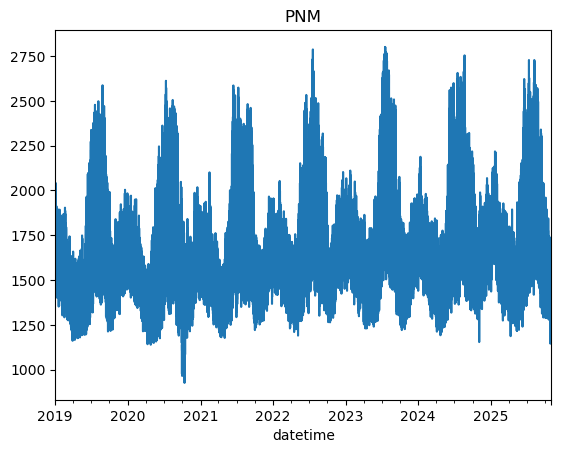

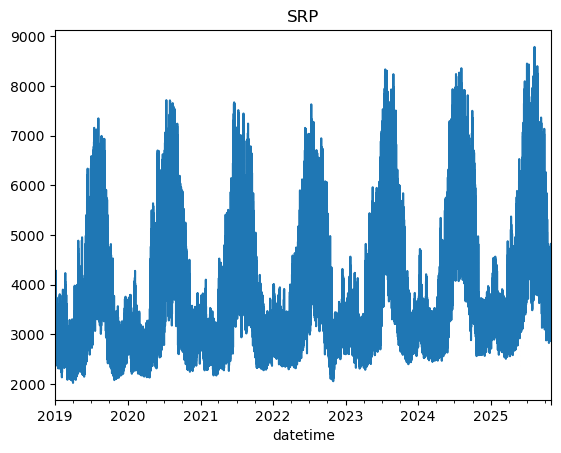

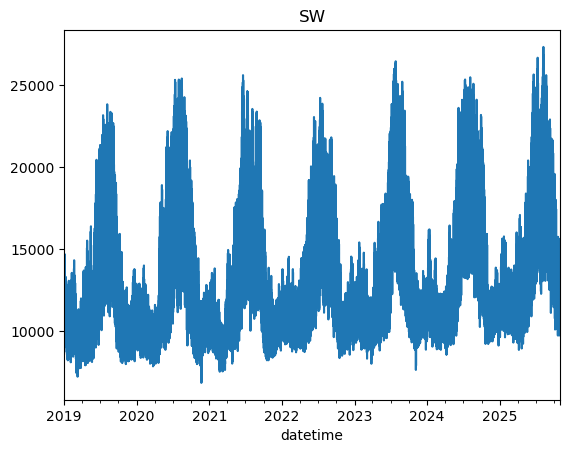

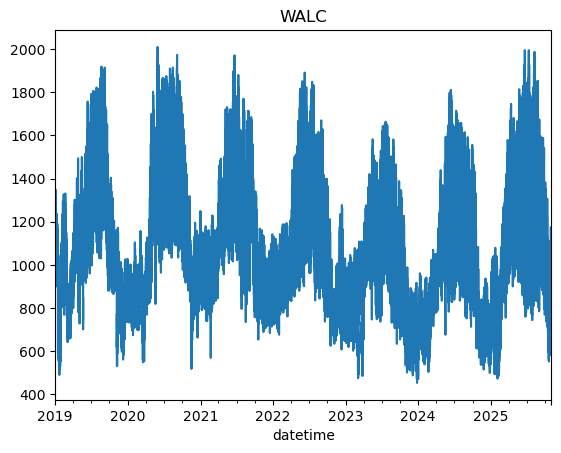

In [3]:
# Clean load data

df_load_clean = df_load.copy()
low_cutoffs = {col: 100 for col in df_load_clean.columns}
low_cutoffs["LDWP"] = 1000
low_cutoffs["WALC"] = 400
for col in df_load.columns:
    
    # Identify large percentage changes in data (indicating erroneous data)
    bwd_pct_change = (df_load_clean[col] + 1).pct_change(periods=1, fill_method=None).abs()
    fwd_pct_change = (df_load_clean[col] + 1).pct_change(periods=-1, fill_method=None).abs()
    pct_change = pd.concat([fwd_pct_change, bwd_pct_change], axis=1).max(axis=1)
    big_deltas = (pct_change > 0.2)
    
    # Identify where time series is below cutoff
    zeros = (df_load_clean[col] < low_cutoffs[col])

    # Flag index at these times
    flag_inds = df_load_clean[col].index[big_deltas | zeros]
    
    # Remove data at these times
    df_load_clean.loc[flag_inds, col] = np.nan
    
    # Identify large rolling z-scores
    window = 168
    rolling_mean = df_load_clean[col].rolling(window=window, min_periods=1, center=True).mean()
    rolling_std = df_load_clean[col].rolling(window=window, min_periods=1, center=True).std()
    rolling_zscore = (df_load_clean[col] - rolling_mean) / rolling_std
    big_zscores = (rolling_zscore > 3)

    # Flag index at these times
    flag_inds = df_load_clean[col].index[big_deltas | zeros | big_zscores]

     # Remove data at these times
    df_load_clean.loc[flag_inds, col] = np.nan

    # Interpolate data
    df_load_clean[col] = df_load_clean[col].interpolate(method="time")
    
    # Plot cleaned data
    df_load_clean[col].plot()
    plt.title(col)
    plt.show()

In [4]:
# Calibrating Demand Ninja parameters with cleaned load data
summer = [5,6,7,8,9,10]
winter = [11,12,1,2,3,4]
shoulder = [4,11]

In [5]:
# Get summer/winter load
df_sw = df_load_clean["SW"]
df_sw_summer = df_sw.loc[df_sw.index.month.isin(summer)]
df_sw_winter = df_sw.loc[df_sw.index.month.isin(winter)]

In [6]:
# Get summer/winter peaks
summer_peaks = df_sw_summer.groupby(df_sw_summer.index.year).max()
winter_peaks = df_sw_winter.groupby(df_sw_winter.index.year).max()

In [7]:
# Ratio of summer to winter peaks
summer_peaks / winter_peaks

datetime
2019    1.536209
2020    1.423407
2021    1.713683
2022    1.587907
2023    1.658098
2024    1.550058
2025    1.600281
Name: SW, dtype: float64

In [8]:
# Get shoulder season baseline demand
shoulder = [3,11]
df_sw_shoulder = df_sw.loc[df_sw.index.month.isin(shoulder)]
shoulder_mins = df_sw_shoulder.groupby(df_sw_shoulder.index.year).min()
summer_peaks / shoulder_mins

datetime
2019    3.305856
2020    3.719244
2021    3.400053
2022    2.815581
2023    3.470472
2024    2.876878
2025    2.948414
Name: SW, dtype: float64